# Customer Churn Prediction

**Business Objective:** Customer churn - when a customer stops using a company's service, directly impacts revenue. This notebook builds and compares multiple classification models to predict whether a customer is likely to churn, so the business can proactively target at-risk customers with retention strategies.

**Target Variable:** `Churn` (binary: 1 = customer churned, 0 = customer retained)

**Dataset:** Customer Churn Dataset, provided as two pre-split files:
- `customer_churn_dataset-training-master.csv` - 440,833 rows, 12 columns
- `customer_churn_dataset-testing-master.csv` - 64,374 rows, 12 columns

**Features:** CustomerID, Age, Gender, Tenure, Usage Frequency, Support Calls, Payment Delay, Subscription Type, Contract Length, Total Spend, Last Interaction

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
train_df = pd.read_csv('customer_churn_dataset-training-master.csv')
test_df = pd.read_csv('customer_churn_dataset-testing-master.csv')
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (440833, 12)
Test shape: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [20]:
print(train_df.info())
print(train_df.isnull().sum())
print(train_df['Churn'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment

In [21]:
train_df = train_df.dropna()
test_df = test_df.dropna()
print("Train shape after dropna:", train_df.shape)
print("Test shape after dropna:", test_df.shape)

Train shape after dropna: (440832, 12)
Test shape after dropna: (64374, 12)


In [22]:
train_df = train_df.drop(columns=['CustomerID'])
test_df = test_df.drop(columns=['CustomerID'])

In [23]:
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    label_encoders[col] = le
train_df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,2,0,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,0,1,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,0,2,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,2,1,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,0,1,617.0,20.0,1.0


In [24]:
X_train = train_df.drop(columns=['Churn'])
y_train = train_df['Churn']
X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Data Preprocessing Summary

- **Missing values:** One row with nulls across all columns was found in both train and test sets and dropped.
- **Irrelevant column:** `CustomerID` was dropped as it holds no predictive value.
- **Categorical encoding:** `Gender`, `Subscription Type`, and `Contract Length` were label-encoded using `LabelEncoder` (fit on train, applied to test).
- **Feature scaling:** `StandardScaler` was applied to features for Logistic Regression. Tree-based models (Decision Tree, Random Forest) used unscaled data since they are not distance-based.
- **Train/test split:** Used the dataset's native pre-split files rather than an artificial split, 440,832 training rows, 64,374 testing rows after cleaning.

## Model Building

Three classification models were trained: Logistic Regression, Decision Tree Classifier and Random Forest Classifier.

In [26]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

In [27]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

In [28]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

In [29]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

===== Logistic Regression =====
Accuracy : 0.5866
Precision: 0.5346
Recall   : 0.9825
F1-Score : 0.6925
Confusion Matrix:
[[ 7804 26077]
 [  533 29960]]



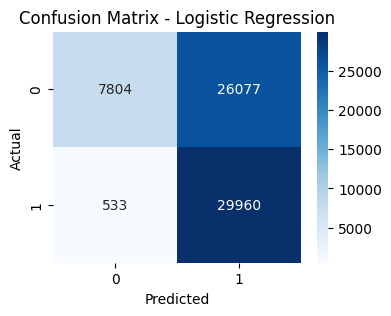

===== Decision Tree =====
Accuracy : 0.5034
Precision: 0.4882
Recall   : 0.9987
F1-Score : 0.6558
Confusion Matrix:
[[ 1949 31932]
 [   39 30454]]



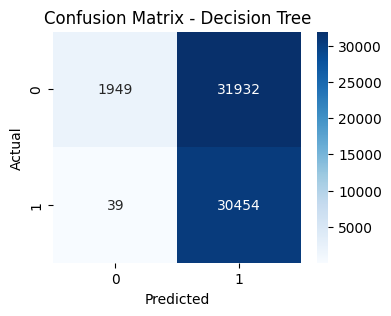

===== Random Forest =====
Accuracy : 0.5034
Precision: 0.4882
Recall   : 0.9987
F1-Score : 0.6558
Confusion Matrix:
[[ 1957 31924]
 [   41 30452]]



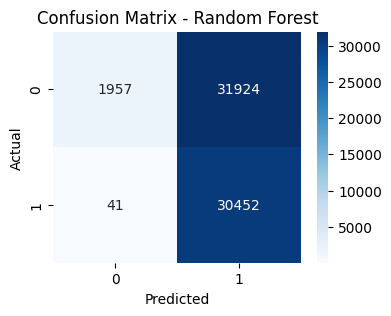

In [30]:
results = []
results.append(evaluate_model("Logistic Regression", y_test, y_pred_log))
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

In [31]:
comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.586634,0.534647,0.982521,0.692477
2,Random Forest,0.503449,0.488201,0.998655,0.655805
1,Decision Tree,0.503355,0.488154,0.998721,0.655778


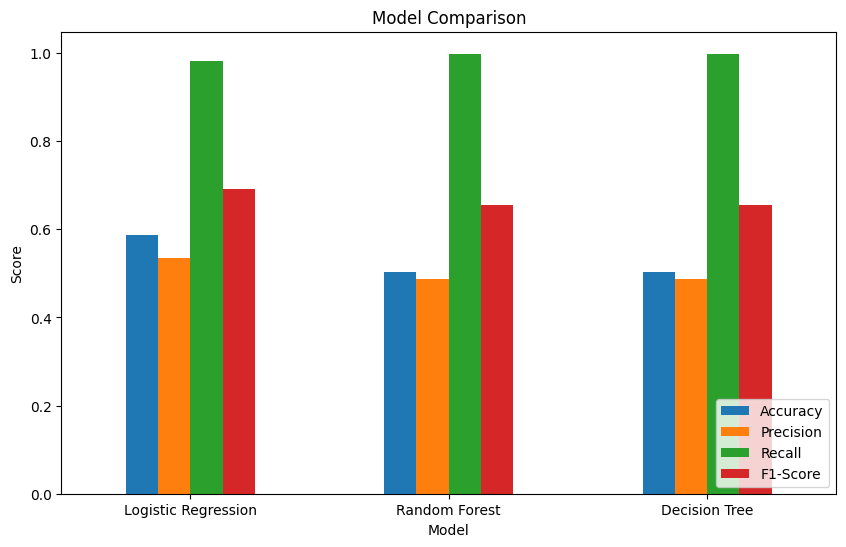

In [32]:
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

## Model Comparison & Conclusion

| Model               | Accuracy | Precision | Recall  | F1-Score |
|----------------------|----------|-----------|---------|----------|
| Logistic Regression  | 0.5866   | 0.5346    | 0.9825  | 0.6925   |
| Random Forest         | 0.5034   | 0.4882    | 0.9987  | 0.6558   |
| Decision Tree         | 0.5034   | 0.4882    | 0.9987  | 0.6558   |

**Best Model: Logistic Regression**, based on F1-Score (0.6925), the highest among the three. While all three models achieve very high recall (~98–99%, meaning they rarely miss actual churners), Logistic Regression has a meaningfully better precision (0.53 vs 0.49), meaning fewer false alarms , customers wrongly flagged as churners. This gives it the best balance between catching churners and avoiding wasted retention spend on customers who wouldn't have churned anyway.

**Key Observations:**
- All models show high recall but modest precision, indicating the models are biased toward predicting churn, likely because the dataset has a large proportion of churned customers.
- Decision Tree and Random Forest produced nearly identical results, suggesting the Random Forest's ensemble averaging added little benefit here, possibly due to default (unpruned) tree depth.
- Overall accuracy across all models (~50–59%) is modest, suggesting there is room to improve with hyperparameter tuning or additional feature engineering.

**Business Recommendations:**
- Deploy Logistic Regression for churn flagging given its best precision-recall balance.
- Since recall is very high across all models, the business can be confident that at-risk customers are being captured, the priority should be reducing false positives to make retention campaigns more cost-effective.

**Future Improvements:**
- Hyperparameter tuning (e.g. GridSearchCV) for Decision Tree and Random Forest, especially limiting tree depth to reduce overfitting.
- Try class balancing techniques (SMOTE, class weights) to improve precision.
- Test additional models (XGBoost, Gradient Boosting).
- Perform feature importance analysis to identify top churn drivers.